In [118]:
import torch
import matplotlib.pyplot as plt

from src.radials.unimodal.elliposoid.centered.data_enclosing import DataEnclosingCenteredEllipsoidRadial
from src.radials.unimodal.elliposoid.offcentered.data_enclosing import DataEnclosingOffCenteredEllipsoidRadial

from src.radials.unimodal.trimmed_ellipsoid.data_enclosing_offcentered import DataEnclosingOffCenteredTrimmedEllipsoidRadial

In [119]:
archetypes = torch.randn(10, 2) + torch.tensor([3.0, 2.0])
center = torch.tensor([3.0, 2.0])  # center of the archetypes

In [120]:
radial = DataEnclosingOffCenteredEllipsoidRadial(archetypes, center)

In [121]:
print(torch.einsum("ij,jk,ik->i", center[None], radial.Sigma_inv, center[None]))
print(torch.einsum("ij,jk,ik->i", archetypes - center, radial.Sigma_inv, archetypes - center))

tensor([0.3612])
tensor([0.0064, 0.0610, 0.0179, 0.5005, 0.0640, 0.1319, 0.0109, 0.5212, 0.4685,
        0.1264])


In [122]:
radial_c = DataEnclosingCenteredEllipsoidRadial(archetypes)

In [123]:
print(torch.einsum("ij,jk,ik->i", archetypes, radial_c.Sigma_inv, archetypes))

tensor([0.2404, 0.5460, 0.2613, 0.7604, 0.5026, 0.3492, 0.3110, 0.4157, 0.7352,
        0.2235])


In [124]:
radial_trimmed = DataEnclosingOffCenteredTrimmedEllipsoidRadial(archetypes, center)

In [125]:
theta = torch.linspace(0, 2 * torch.pi, 100)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)

ellipsoid = radial(circle).unsqueeze(1) * circle 
ellipsoid_c = radial_c(circle).unsqueeze(1) * circle
ellipsoid_trimmed = radial_trimmed(circle).unsqueeze(1) * circle

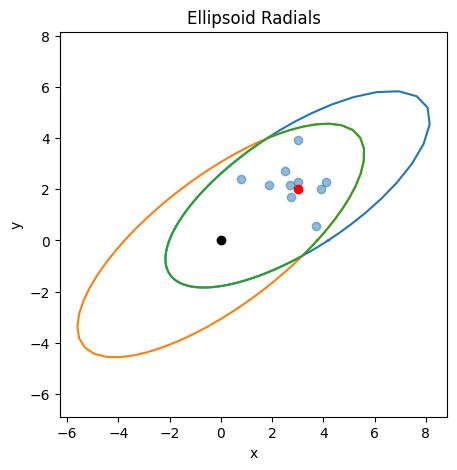

In [126]:
plt.figure(figsize=(5, 5))
plt.scatter(archetypes[:, 0], archetypes[:, 1], alpha=0.5, label="Archetypes")
plt.plot(ellipsoid[:, 0], ellipsoid[:, 1], label="Centered Gaussian Ellipsoid Radial")
plt.plot(ellipsoid_c[:, 0], ellipsoid_c[:, 1], label="Off-Centered Gaussian Ellipsoid Radial")
plt.plot(ellipsoid_trimmed[:, 0], ellipsoid_trimmed[:, 1], label="Trimmed Ellipsoid Radial")
plt.scatter(center[0], center[1], color='red', label="mu")
plt.scatter(0, 0, color='black', label="origin")
plt.title("Ellipsoid Radials")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-2, 6)
plt.ylim(-2, 6)
plt.axis('equal')
plt.show()